# 🎓 Perceptrón: ¿Un estudiante aprueba o no una materia?

En este ejemplo, un **Perceptrón** aprende a predecir si un estudiante aprueba una materia utilizando dos características:

- **X₁:** porcentaje de asistencia
- **X₂:** porcentaje de trabajos prácticos aprobados
- **y = 0:** No aprueba ❌
- **y = 1:** Aprueba ✅

## 1. Importar las bibliotecas

Utilizaremos NumPy para trabajar con los datos, Matplotlib para visualizar el resultado y el Perceptrón de `scikit-learn` para entrenar el modelo.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron

## 2. Crear los datos de los estudiantes

Cada fila representa a un estudiante. Las dos primeras columnas son las características y `y` contiene el resultado esperado.

In [ ]:
X = np.array([
    [50, 40],
    [60, 50],
    [65, 60],
    [66, 55],
    [55, 60],
    [70, 70],
    [75, 70],
    [80, 80],
    [90, 90],
    [95, 85]
])

y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

print("Datos X:")
print(X)
print("\nResultados y:")
print(y)

Datos X:
[[50 40]
 [60 50]
 [65 60]
 [66 55]
 [55 60]
 [70 70]
 [75 70]
 [80 80]
 [90 90]
 [95 85]]

Resultados y:
[0 0 0 0 0 1 1 1 1 1]


In [ ]:
X_test = np.array([
    [50, 55],
    [45, 50],
    [85, 70],
    [75, 75],

])

y_test = np.array([0, 0, 1, 1])


## 3. Visualizar los datos

En el gráfico podemos observar los estudiantes que no aprueban y los que aprueban.
no aprueban: los primeros 3 que cumple y==0
(50,40)
(60,50)
(65,60)

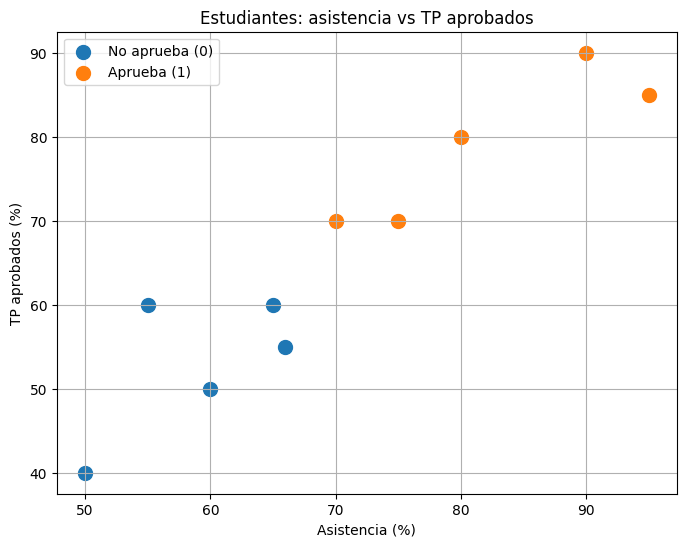

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(X[y == 0, 0], X[y == 0, 1], label='No aprueba (0)', s=100)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Aprueba (1)', s=100)

plt.xlabel('Asistencia (%)')
plt.ylabel('TP aprobados (%)')
plt.title('Estudiantes: asistencia vs TP aprobados')
plt.legend()
plt.grid(True)
plt.show()

## 4. Crear y entrenar el Perceptrón

El Perceptrón buscará una frontera de decisión que permita separar los ejemplos con `y = 0` de los ejemplos con `y = 1`.

In [ ]:
modelo = Perceptron(max_iter=2000, random_state=42, eta0=0.001)
modelo.fit(X, y)

print("Pesos aprendidos:")
print(modelo.coef_)

print("\nBias aprendido:")
print(modelo.intercept_)

Pesos aprendidos:
[[0.072 0.09 ]]

Bias aprendido:
[-0.005]


## 5. Realizar predicciones sobre los datos de entrenamiento

In [ ]:
valor_nuevo = np.array([[10, 10]])
predicciones = modelo.predict(valor_nuevo)

print("Predicción:     ", predicciones)

Predicción:      [1]


## 6. Probar con nuevos estudiantes

Ahora utilizamos el Perceptrón para predecir estudiantes que no estaban en los datos de entrenamiento.

In [ ]:
nuevos_estudiantes = np.array([
    [50, 40],
    [10, 45],
    [40, 65],
    [90, 80]
])

predicciones_nuevas = modelo.predict(nuevos_estudiantes)
print(predicciones_nuevas)

for estudiante, prediccion in zip(nuevos_estudiantes, predicciones_nuevas):
    resultado = 'APRUEBA ✅' if prediccion == 1 else 'NO APRUEBA ❌'
    print(f"Asistencia: {estudiante[0]}% | TP aprobados: {estudiante[1]}% → {resultado}")

[1 1 1 1]
Asistencia: 50% | TP aprobados: 40% → APRUEBA ✅
Asistencia: 10% | TP aprobados: 45% → APRUEBA ✅
Asistencia: 40% | TP aprobados: 65% → APRUEBA ✅
Asistencia: 90% | TP aprobados: 80% → APRUEBA ✅


## 7. Mostrar la frontera de decisión

La frontera de decisión representa la separación que aprendió el Perceptrón entre las dos clases.

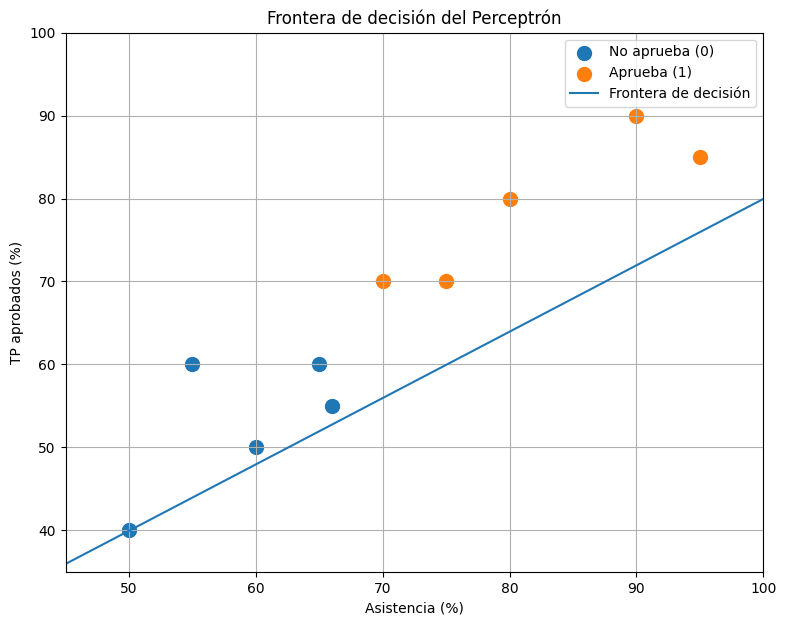

In [ ]:
plt.figure(figsize=(9, 7))

plt.scatter(X[y == 0, 0], X[y == 0, 1], label='No aprueba (0)', s=100)
plt.scatter(X[y == 1, 0], X[y == 1, 1], label='Aprueba (1)', s=100)

w1, w2 = modelo.coef_[0]
b = modelo.intercept_[0]

x_values = np.linspace(45, 100, 100)
y_values = (w1 * x_values + b) / w2

plt.plot(x_values, y_values, label='Frontera de decisión')

plt.xlabel('Asistencia (%)')
plt.ylabel('TP aprobados (%)')
plt.title('Frontera de decisión del Perceptrón')
plt.legend()
plt.grid(True)
plt.xlim(45, 100)
plt.ylim(35, 100)
plt.show()

## 8. ¿Cómo toma la decisión el Perceptrón?

El modelo calcula una suma ponderada:

$$z = X_1w_1 + X_2w_2 + b$$

Luego aplica una función de decisión. En términos sencillos:

- Si el resultado es suficiente para superar el umbral → **1: Aprueba** ✅
- Si no supera el umbral → **0: No aprueba** ❌

Los pesos (`w₁`, `w₂`) indican cuánto influyen la asistencia y los trabajos prácticos en la decisión.

## 9. Conclusión

El Perceptrón aprende a partir de ejemplos. No le indicamos directamente una regla como 'con 70% de asistencia aprueba'. En cambio, observa los ejemplos proporcionados, ajusta sus pesos y encuentra una frontera que intenta separar las dos clases.

⚠️ **Importante:** este es un ejemplo didáctico. En una situación real, aprobar una materia puede depender de muchas otras variables y de reglas institucionales.